In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf
import datetime as dt

In [3]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


In [4]:
model = yaml_import('yamlDSGE/rbc.yaml')

In [5]:
# model.residuals()

In [6]:
# print(model)

In [7]:
# # Run model simulation and realised output check for the window considered
# def get_prior_quarter_date(date_input):
#     return date_input[:5] + (("0" + str(int(date_input[5:7]) - 3)) if int(date_input[5:7]) != 3 else str(12)) + date_input[7:]

# window_start = "2024-09-30"
# window_end = "2025-09-30"
# data_length_years = 10
# data_length_quarters = data_length_years * 4
# data_start_gdp = str(int(window_start[:4]) - data_length_years) + window_start[4:] # Data starts 10 years prior to window start
# data_start_prod = get_prior_quarter_date(data_start_gdp) # Data starts one quarter prior to GDP data for next-period forecasting
# data_end_prod = get_prior_quarter_date(window_end) # Data ends one quarter before window end as the final forecast must be of the window end date

In [161]:
window_start_in = "2024-09-30"
window_end_in = "2025-09-30"

def convert_str_date_to_dt(date_in):
    return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

window_start = convert_str_date_to_dt(window_start_in)
window_end = convert_str_date_to_dt(window_end_in)

# Run model simulation and realised output check for the window considered
def get_prior_date(date_input, date_offset_months):
    return (
        ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) - pd.tseries.offsets.DateOffset(months=date_offset_months)) 
        + pd.tseries.offsets.BMonthEnd()
    ).date()

def add_buffer_for_start_offset(offset_months):
    return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

data_length_years = 10
data_length_quarters = data_length_years * 4
data_length_months = data_length_years * 12
months_in_quarter = 3

data_start_gdp = get_prior_date(window_start, add_buffer_for_start_offset(data_length_months)) # Data starts 10 years prior to window start
data_start_prod = get_prior_date(data_start_gdp, months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
data_end_prod = get_prior_date(window_end, 3) # Data ends one quarter before window end as the final forecast must be of the window end date

In [149]:
def convert_fred_index_to_qe(index_dates):
    return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]

In [187]:
# Non-farm business labor productivity index
prod = pdr.DataReader("OPHNFB", "fred", start=data_start_prod, end=data_end_prod)
# prod.index = prod.index.to_period("Q")
# prod.index = prod.index.date
prod_index_name = prod.index.name
prod.index = convert_fred_index_to_qe(prod.index)
prod.index.name = prod_index_name
prod = prod.dropna()

# Real GDP
gdp = pdr.DataReader("GDPC1", "fred", start=data_start_gdp, end=window_end)
# gdp.index = gdp.index.to_period("Q")
# gdp.index = gdp.index.date
gdp_index_name = gdp.index.name
gdp.index = convert_fred_index_to_qe(gdp.index)
gdp.index.name = gdp_index_name
gdp = gdp.dropna()

assert len(prod) == len(gdp)

In [190]:
prod_index_name = prod.index.name
window_start_prod = get_prior_date(window_start, 3) # Window starts one quarter prior to GDP data for next-period forecasting
window_prod = prod[(prod.index >= window_start_prod) & (prod.index <= data_end_prod)]
window_prod

,OPHNFB
DATE,
2024-06-28,114.947
2024-09-30,115.989
2024-12-31,116.394
2025-03-31,116.127
2025-06-30,117.319


In [176]:
# for q in window_prod.index:
#     if q == window_prod.index[0]:
#         prod_data_test = prod[(prod.index >= get_prior_date(q, data_length_months)) & (prod.index <= q)]
#         print(prod_data_test.index)
#         print(len(prod_data_test.index))
#         assert len(prod_data_test.index) == data_length_quarters + 1

Index([2014-06-30, 2014-09-30, 2014-12-31, 2015-03-31, 2015-06-30, 2015-09-30,
       2015-12-31, 2016-03-31, 2016-06-30, 2016-09-30, 2016-12-30, 2017-03-31,
       2017-06-30, 2017-09-29, 2017-12-29, 2018-03-30, 2018-06-29, 2018-09-28,
       2018-12-31, 2019-03-29, 2019-06-28, 2019-09-30, 2019-12-31, 2020-03-31,
       2020-06-30, 2020-09-30, 2020-12-31, 2021-03-31, 2021-06-30, 2021-09-30,
       2021-12-31, 2022-03-31, 2022-06-30, 2022-09-30, 2022-12-30, 2023-03-31,
       2023-06-30, 2023-09-29, 2023-12-29, 2024-03-29, 2024-06-28],
      dtype='object')
41


In [191]:
latest_quarters = []
output_forecasts = []
for q in window_prod.index:
    # prod_data = prod[(prod.index >= q - data_length_quarters) & (prod.index <= q)]
    prod_data = prod[(prod.index >= get_prior_date(q, data_length_months)) & (prod.index <= q)]
    assert len(prod_data.index) == data_length_quarters + 1
    
    prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
    # prod_cycle.plot()
    
    a_hat = prod_cycle
    a = a_hat
    a_lag = a.shift()
    
    y = a.iloc[1:]
    X = a_lag.iloc[1:].values
    
    ar1 = OLS(y.values, X).fit()
    
    rho_hat = ar1.params[0]
    print(f"Estimated rho: {rho_hat:.3f}")

    eps_hat = pd.Series(
        ar1.resid,
        index=y.index,
        name="tfp_shock"
    )
    # eps_hat.plot()
    
    latest_quarter = eps_hat.index[-1]
    latest_shock = eps_hat.iloc[-1]
    
    print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")

    # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
    model.set_calibration(rho=rho_hat)
    # print(model.calibration.flat)

    #dr = time_iteration(model)
    dr = perturb(model, order=1)
    
    irf = response(model, dr, 'e_z', T=10, impulse=float(latest_shock))
    
    # plt.figure(figsize=(8,4))
    # plt.subplot(221)
    # plt.plot(irf.sel(V='z'))
    # plt.title('Productivity')
    # plt.grid()
    # plt.subplot(222)
    # plt.plot(irf.sel(V='y'))
    # plt.title('Output')
    # plt.grid()
    # plt.subplot(223)
    # plt.plot(irf.sel(V='i'))
    # plt.title('Investment')
    # plt.grid()
    # plt.subplot(224)
    # plt.plot(irf.sel(V='c'))
    # plt.title('Consumption')
    # plt.grid()
    # plt.tight_layout()
    
    irf_output = np.array(irf.sel(V='y'))
    
    irf_output = [(x - 1) for x in irf_output]
    output_forecast = irf_output[2]
    print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
    latest_quarters.append(latest_quarter)
    output_forecasts.append(output_forecast)

Estimated rho: 0.781
Estimated TFP shock for 2024-06-28: 0.0050
10 [0.00504428]
Next period IRF forecast as of 2024-06-28: 0.00160
Estimated rho: 0.780
Estimated TFP shock for 2024-09-30: 0.0055
10 [0.00546975]
Next period IRF forecast as of 2024-09-30: 0.00216
Estimated rho: 0.787
Estimated TFP shock for 2024-12-31: 0.0005
10 [0.00052244]
Next period IRF forecast as of 2024-12-31: -0.00427
Estimated rho: 0.779
Estimated TFP shock for 2025-03-31: -0.0053
10 [-0.00533108]
Next period IRF forecast as of 2025-03-31: -0.01182
Estimated rho: 0.771
Estimated TFP shock for 2025-06-30: 0.0054
10 [0.00539829]
Next period IRF forecast as of 2025-06-30: 0.00210


In [192]:
output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
output_forecasts_ser.name = "output_forecast"
output_forecasts_ser.index.name = prod_index_name
output_forecasts_df = output_forecasts_ser.to_frame()
output_forecasts_df

,output_forecast
DATE,
2024-06-28,0.001605
2024-09-30,0.002162
2024-12-31,-0.004268
2025-03-31,-0.011824
2025-06-30,0.002099


In [193]:
gdp_index_name = gdp.index.name
window_gdp = gdp[(gdp.index >= window_start) & (gdp.index <= window_end)]
window_gdp

,GDPC1
DATE,
2024-09-30,23478.570
2024-12-31,23586.542
2025-03-31,23548.210
2025-06-30,23770.976
2025-09-30,24026.834


In [194]:
latest_quarters_gdp = []
outputs_realised = []
for q in window_gdp.index:
    # gdp_data = gdp[(gdp.index >= q - data_length_quarters) & (gdp.index <= q)]
    gdp_data = gdp[(gdp.index >= get_prior_date(q, data_length_months)) & (gdp.index <= q)]
    assert len(gdp_data.index) == data_length_quarters + 1

    gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
    output_gap = gdp_cycle
    # latest_quarter_gdp = output_gap.last_valid_index().strftime(None)
    latest_quarter_gdp = output_gap.last_valid_index()
    output_realised = output_gap.iloc[-1]
    print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
    
    latest_quarters_gdp.append(latest_quarter_gdp)
    outputs_realised.append(output_realised)

Current period realised value as of 2024-09-30: 0.00310
Current period realised value as of 2024-12-31: 0.00041
Current period realised value as of 2025-03-31: -0.00672
Current period realised value as of 2025-06-30: -0.00343
Current period realised value as of 2025-09-30: 0.00031


In [195]:
outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
outputs_realised_ser.name = "output_realised"
outputs_realised_ser.index.name = gdp_index_name
outputs_realised_df = outputs_realised_ser.to_frame()
# outputs_realised_df.index = pd.PeriodIndex(outputs_realised_df.index, freq="Q-DEC")
outputs_realised_df

,output_realised
DATE,
2024-09-30,0.003100
2024-12-31,0.000410
2025-03-31,-0.006721
2025-06-30,-0.003433
2025-09-30,0.000310


In [196]:
signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
signals = outputs_realised_df.join(output_forecasts_mod_df)

def determine_pos(row):
    if row["output_forecast"] > row["output_realised"]:
        pos = 1
    elif row["output_forecast"] < row["output_realised"]:
        pos = -1
    else:
        pos = 0
    return pos

signals["pos"] = signals.apply(determine_pos, axis=1)
signals

,output_realised,output_forecast,pos
DATE,,,
2024-09-30,0.003100,0.001605,-1
2024-12-31,0.000410,0.002162,1
2025-03-31,-0.006721,-0.004268,1
2025-06-30,-0.003433,-0.011824,-1
2025-09-30,0.000310,0.002099,1


In [18]:
# S&P 500
# asset = yf.Ticker("^GSPC").history(start=window_start, end=window_end)["Close"]
asset = yf.Ticker("^GSPC").history(start=window_start, end="2025-10-01")["Close"] # end date in yahoo finance query is off by 1 day - check fix for end date

In [19]:
asset_ser = asset.copy()
asset_ser_name = asset_ser.index.name
asset_ser.index = asset_ser.index.date
asset_ser.index.name = asset_ser_name
asset_ser

Date
2024-09-30    5762.479980
2024-10-01    5708.750000
2024-10-02    5709.540039
2024-10-03    5699.939941
2024-10-04    5751.069824
                 ...     
2025-09-24    6637.970215
2025-09-25    6604.720215
2025-09-26    6643.700195
2025-09-29    6661.209961
2025-09-30    6688.459961
Name: Close, Length: 251, dtype: float64

In [20]:
type(window_start)

str

In [21]:
# change date type from str to date throughout processing - check above

In [50]:
signals.index[0].to_timestamp().date()
#.to_date()

datetime.date(2024, 7, 1)

In [41]:
asset_ser.to_frame()

,Close
Date,
2024-09-30,5762.479980
2024-10-01,5708.750000
2024-10-02,5709.540039
2024-10-03,5699.939941
2024-10-04,5751.069824
...,...
2025-09-24,6637.970215
2025-09-25,6604.720215
2025-09-26,6643.700195


In [22]:
window_start_date = dt.date(int(window_start[0:4]), int(window_start[5:7]), int(window_start[8:10]))
window_end_date = dt.date(int(window_end[0:4]), int(window_end[5:7]), int(window_end[8:10]))

In [23]:
# Calculate the difference in months between end_date and start_date
months_in_year = 12
month_delta = (window_end_date.year - window_start_date.year) * months_in_year + window_end_date.month - window_start_date.month

# Prepare a list of offsets to generate the right year-month combinations of the designated roll dates
comprehensive_delta_init = [[mon // months_in_year, mon % months_in_year] for mon in range(month_delta + window_start_date.month)] # Purposely go beyond month_delta as start_date can be intra-year and shift the offsets

# Adjust the offsets returned based on start_date position in the year
comprehensive_delta = [[y, m - window_start_date.month + 1] for y, m in comprehensive_delta_init][window_start_date.month - 1:] # Final offset list begins several elements in to match an intra-year start_date

In [24]:
comprehensive_delta

[[0, 0],
 [0, 1],
 [0, 2],
 [0, 3],
 [1, -8],
 [1, -7],
 [1, -6],
 [1, -5],
 [1, -4],
 [1, -3],
 [1, -2],
 [1, -1],
 [1, 0]]

In [25]:
# Create a list of roll dates, taking into accounts offsets and the relevant business day per month (assuming every weekday is a business day)
date_range_full = [
    (dt.date(window_start_date.year + y, window_start_date.month + m, 1) + pd.tseries.offsets.BMonthEnd()).date()
    for y, m in comprehensive_delta 
] # Start on the first business day of the month, then consider roll_date business days after that

date_range_quarters = [d for d in date_range_full if d.month in [3, 6, 9, 12]]

date_range_quarters

[datetime.date(2024, 9, 30),
 datetime.date(2024, 12, 31),
 datetime.date(2025, 3, 31),
 datetime.date(2025, 6, 30),
 datetime.date(2025, 9, 30)]

In [39]:
asset_lim_ser = asset_ser[asset_ser.index.isin(date_range_quarters)]
asset_lim_ser.index = pd.PeriodIndex(asset_lim_ser.index, freq="Q-DEC")
asset_lim_df = asset_lim_ser.to_frame()
asset_lim_df

,Close
Date,
2024Q3,5762.479980
2024Q4,5881.629883
2025Q1,5611.850098
2025Q2,6204.950195
2025Q3,6688.459961


In [40]:
signals_fin = signals.join(asset_lim_df)
signals_fin

,output_realised,output_forecast,pos,Close
DATE,,,,
2024Q3,0.003096,0.001628,-1,5762.479980
2024Q4,0.000410,0.002162,1,5881.629883
2025Q1,-0.006721,-0.004268,1,5611.850098
2025Q2,-0.003433,-0.011824,-1,6204.950195
2025Q3,0.000310,0.002099,1,6688.459961


In [ ]:
gdp.index = gdp.index.to_period("Q")


<Axes: xlabel='Date'>

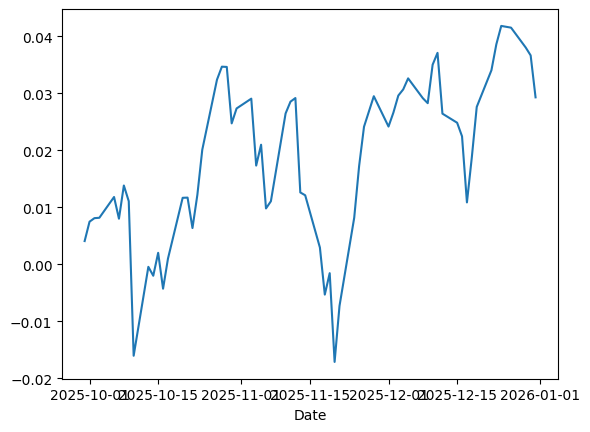

In [97]:
return_ser = asset_ser.pct_change()
return_ser.name = "Return"
# return_ser_2025q3 = return_ser.where((return_ser.index >= dt.date(2025, 9, 30)) & (return_ser.index <= dt.date(2025, 12, 31)), 0)
return_ser_2025q3 = return_ser[(return_ser.index >= dt.date(2025, 9, 30)) & (return_ser.index <= dt.date(2025, 12, 31))]
return_ser_2025q3.cumsum().plot()

In [103]:
return_ser_2025q3.sum()

0.029301988137998558

In [105]:
return_ser_2025q3_mean = return_ser_2025q3.mean()
return_ser_2025q3_mean

0.0004507998175076701

In [106]:
return_ser_2025q3_std = return_ser_2025q3.std()
return_ser_2025q3_std

0.007903444934877515

In [108]:
return_ser_2025q3_sr = return_ser_2025q3_mean / return_ser_2025q3_std
return_ser_2025q3_sr

0.05703839543669276